# ProXtal-LM — Publication-Quality Figures

This notebook generates journal-ready plots from ProXtal-LM training metrics.
All figures use a colour-blind-friendly palette, consistent axis labelling,
and 300 DPI output suitable for submission to peer-reviewed journals.

**Model:** CrystalTriangularModel — predicts crystal distograms from
ESM-C protein embeddings using pair-biased attention and triangle
multiplicative updates.

**Dataset:** Crystal contact maps derived from PDB structures, split into
train/validation/test sets with polymorph flattening.

In [1]:
import sys
sys.path.insert(0, '..')

from scripts.publication_graphs import (
    plot_training_curves,
    plot_precision_recall,
    plot_crystal_metrics,
    plot_auprc,
    plot_hypothesis_losses,
    plot_summary_dashboard,
    plot_metric_comparison,
    generate_all,
)

In [2]:
# Path to training metrics CSV
CSV_PATH = '../checkpoints/v7_esmc_0/training_metrics.csv'

## Figure 1 — Training & Validation Loss

**Description.** Cross-entropy loss over training epochs for the ProXtal-LM
crystal distogram model (v8, ESM-C embeddings, 3-hypothesis architecture).
The left panel shows categorical cross-entropy on the training and
validation sets; the dashed vertical line marks the epoch with the lowest
validation loss. The right panel shows the learning rate schedule.

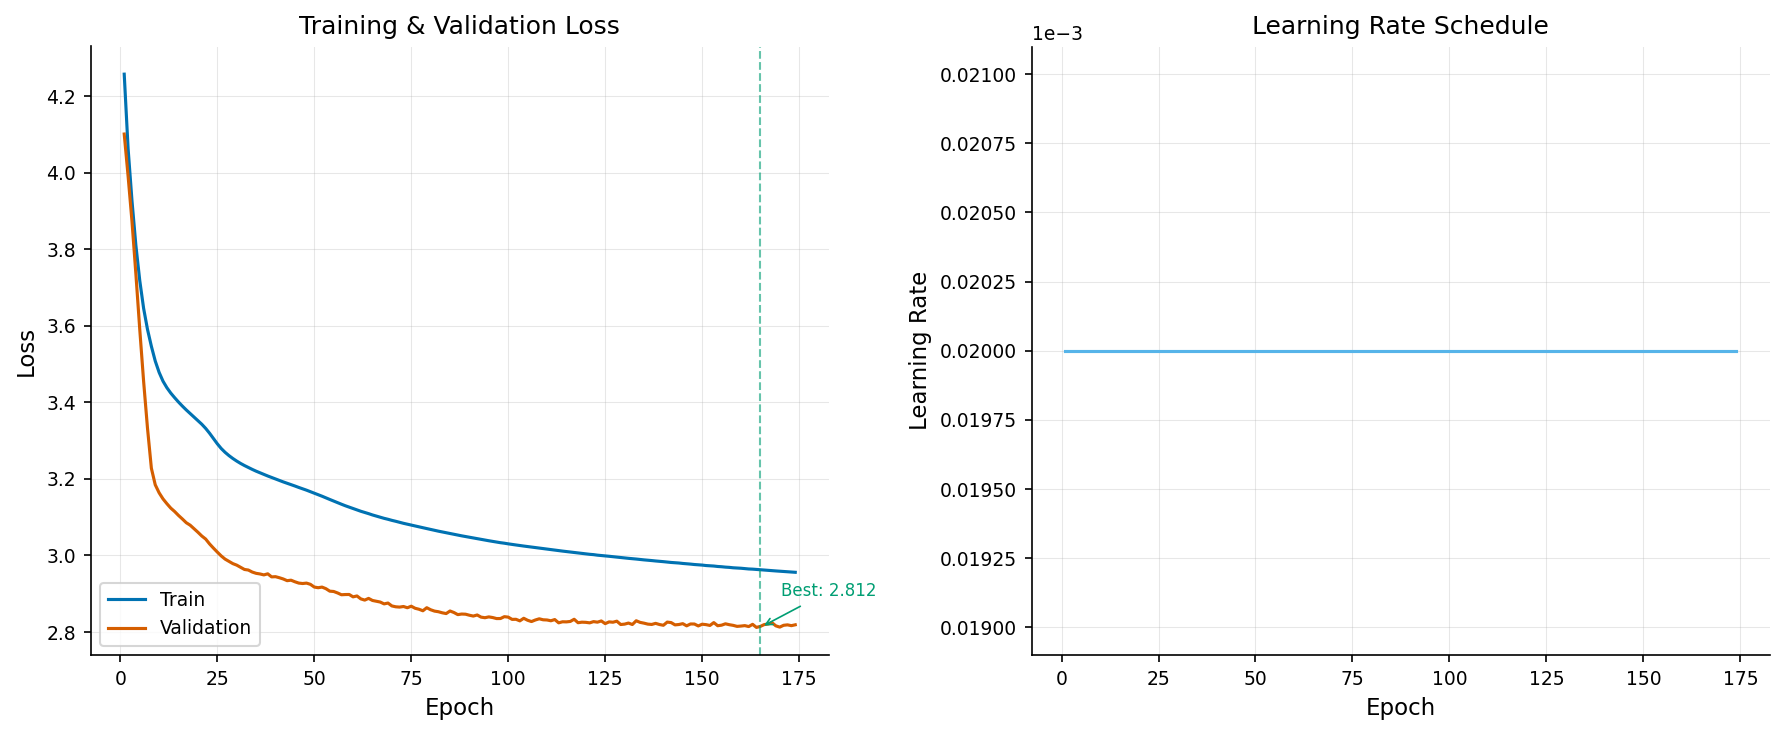

In [3]:
fig = plot_training_curves(CSV_PATH, mode='view')

## Figure 2 — Contact Prediction: Precision, Recall & F1

**Description.** Top-*L* contact prediction performance across training.
**(a)** Precision at three thresholds: *L* (all predicted contacts),
*L*/2, and *L*/5 (highest-confidence contacts only), where *L* is the
sequence length. **(b)** Recall at *L* — the fraction of true contacts
recovered. **(c)** F1 score at *L*, the harmonic mean of precision and
recall. Metrics are computed on the upper triangle of the distance matrix
with a minimum sequence separation of 6 residues (intra-chain) and no
separation filter for inter-chain pairs.

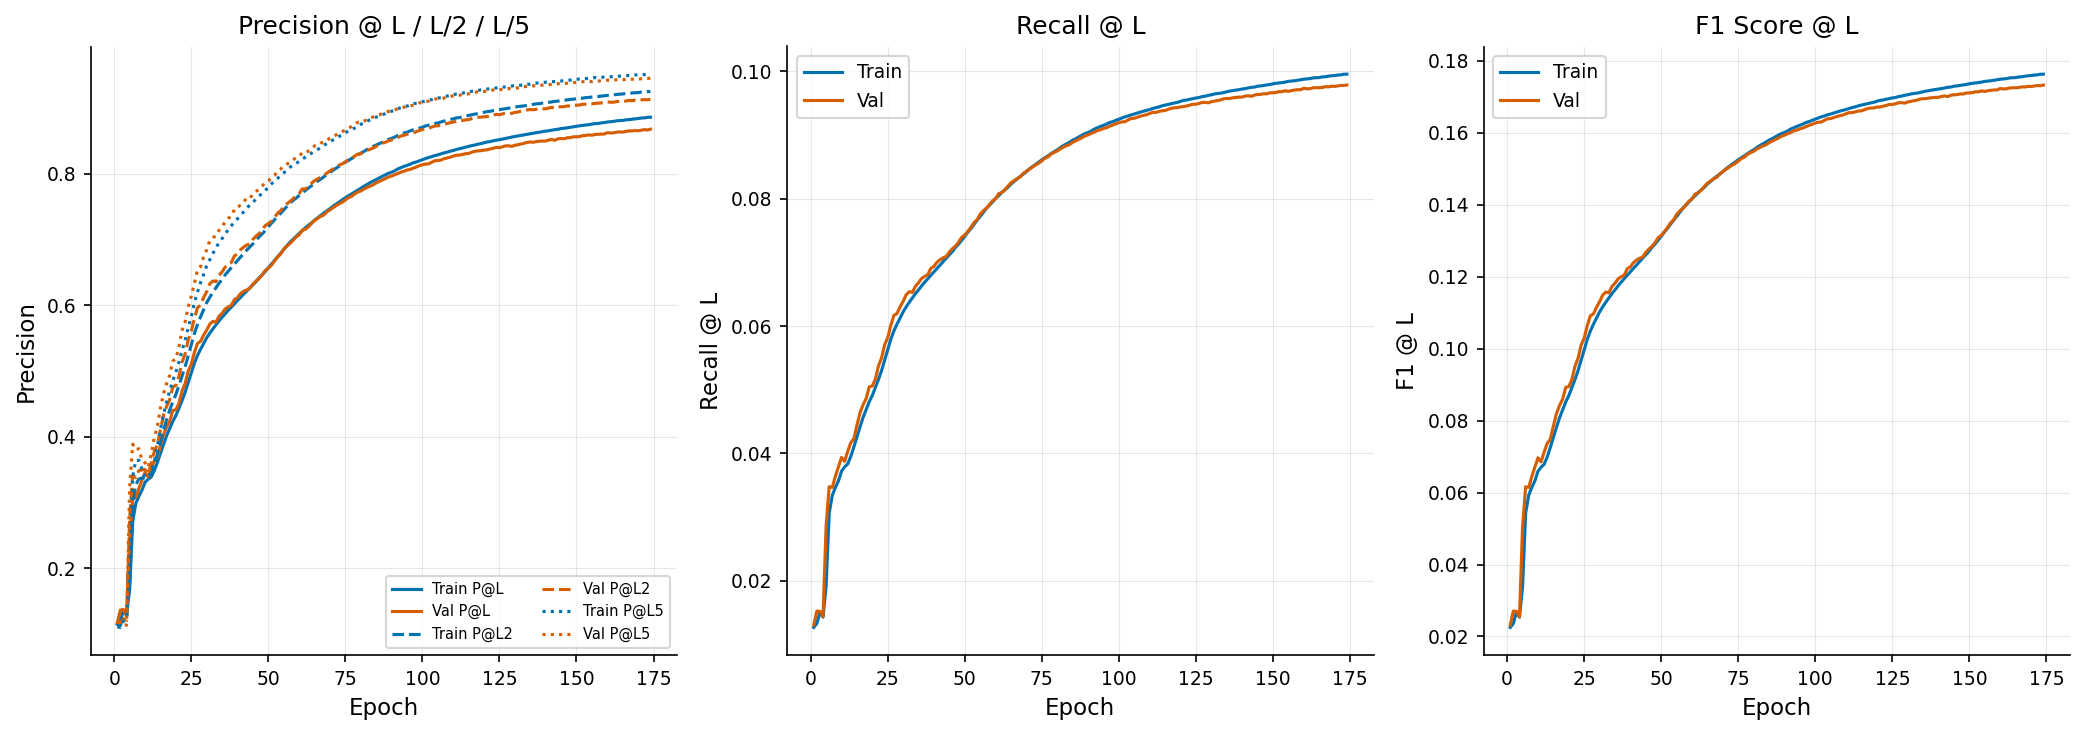

In [4]:
fig = plot_precision_recall(CSV_PATH, mode='view')

## Figure 3 — Crystal-Specific Contact Metrics

**Description.** Performance evaluated **only** on residue pairs where the
crystal distogram differs from the original PDB distogram — i.e. the
inter-molecular crystal-packing contacts that the model must learn to
predict. **(a)** Crystal-only precision at *L*, *L*/2, and *L*/5.
**(b)** Crystal-only bin accuracy (fraction of changed positions where the
predicted distance bin matches the ground truth). **(c)** Percentage of
residue pairs that differ between the original and crystal structures,
reflecting the extent of lattice-induced contact rearrangement.

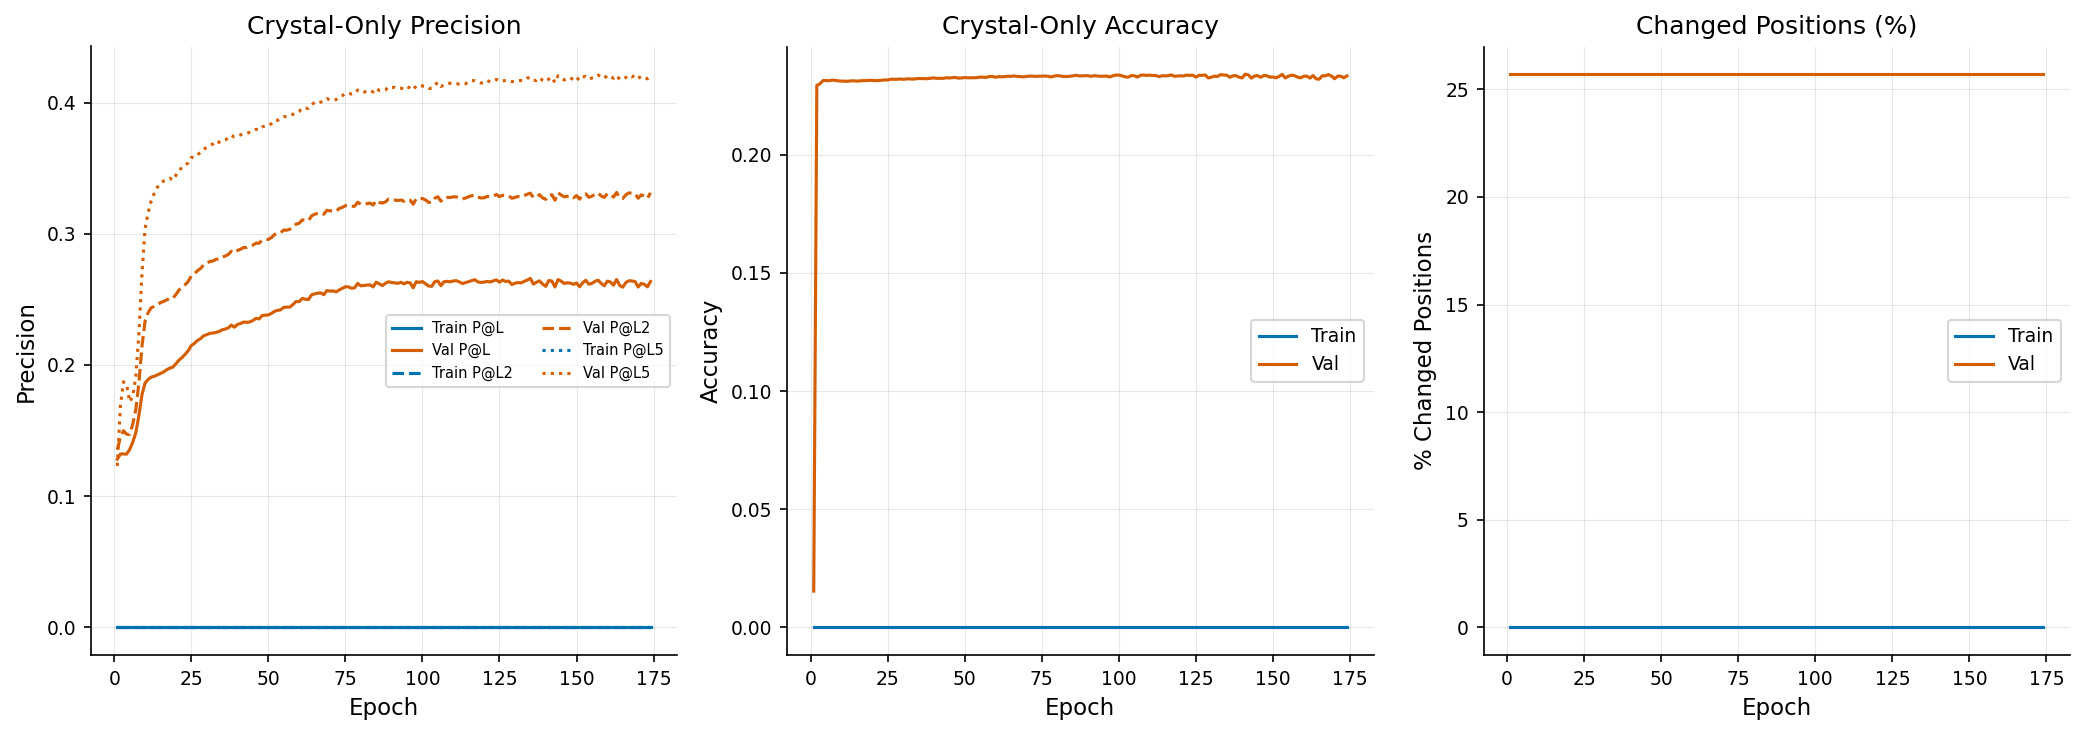

In [5]:
fig = plot_crystal_metrics(CSV_PATH, mode='view')

## Figure 4 — Area Under the Precision–Recall Curve (AUPRC)

**Description.** AUPRC provides a threshold-independent measure of
contact-prediction quality, summarising the precision–recall trade-off
across all confidence thresholds. Unlike precision at a fixed *k*, AUPRC
is insensitive to the choice of top-*k* cutoff and accounts for the
class imbalance inherent in contact prediction (most residue pairs are
not in contact).

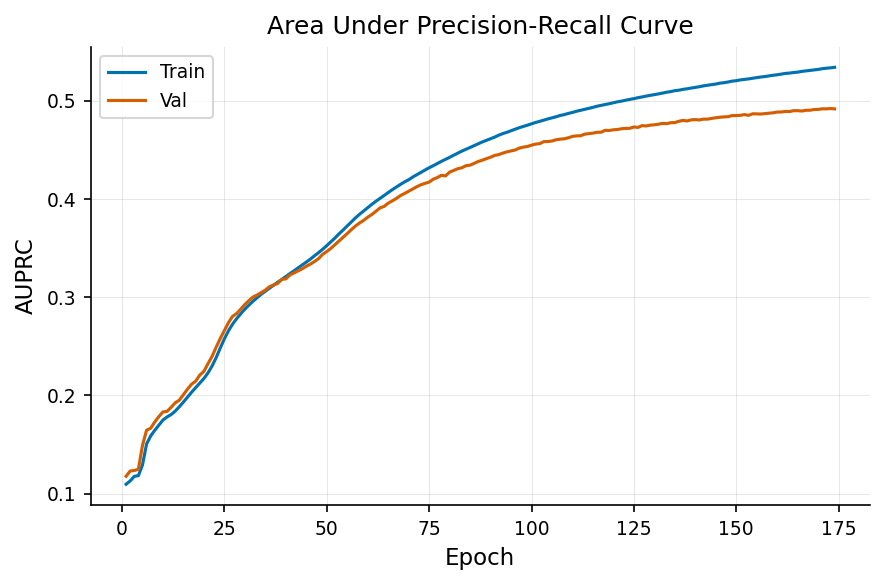

In [6]:
fig = plot_auprc(CSV_PATH, mode='view')

## Figure 5 — Multi-Hypothesis Validation Losses

**Description.** The model produces *N* = 3 independent distogram
hypotheses from a shared pair representation, enabling it to capture
crystal polymorphism. **(a)** Best-matching hypothesis loss per epoch:
for each hypothesis, the loss against its best-matching target polymorph.
**(b)** Full per-hypothesis per-target loss matrix, showing cross-losses
between all hypothesis–target pairs. Convergence of these losses indicates
that hypotheses are specialising to distinct crystal forms.

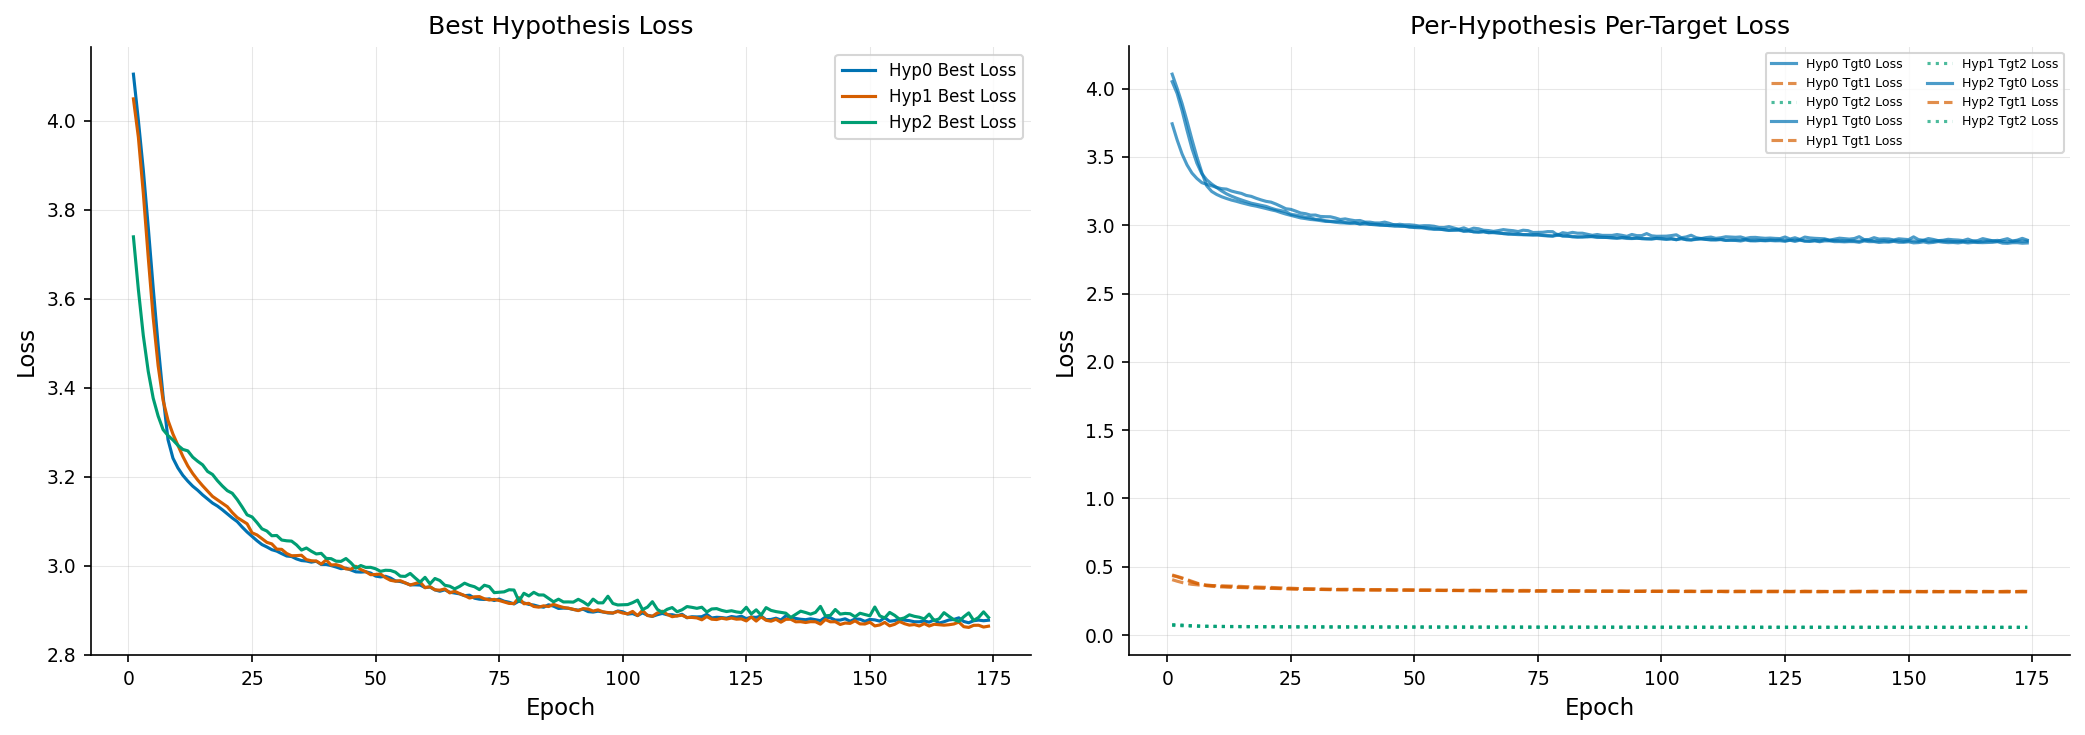

In [7]:
fig = plot_hypothesis_losses(CSV_PATH, mode='view')

## Figure 6 — Summary Dashboard

**Description.** Consolidated 2 × 3 overview of the key training metrics:
loss, precision at *L*, AUPRC, F1 at *L*, crystal-only precision at *L*,
and crystal-only accuracy. This panel provides a single at-a-glance view
of model convergence and generalisation.

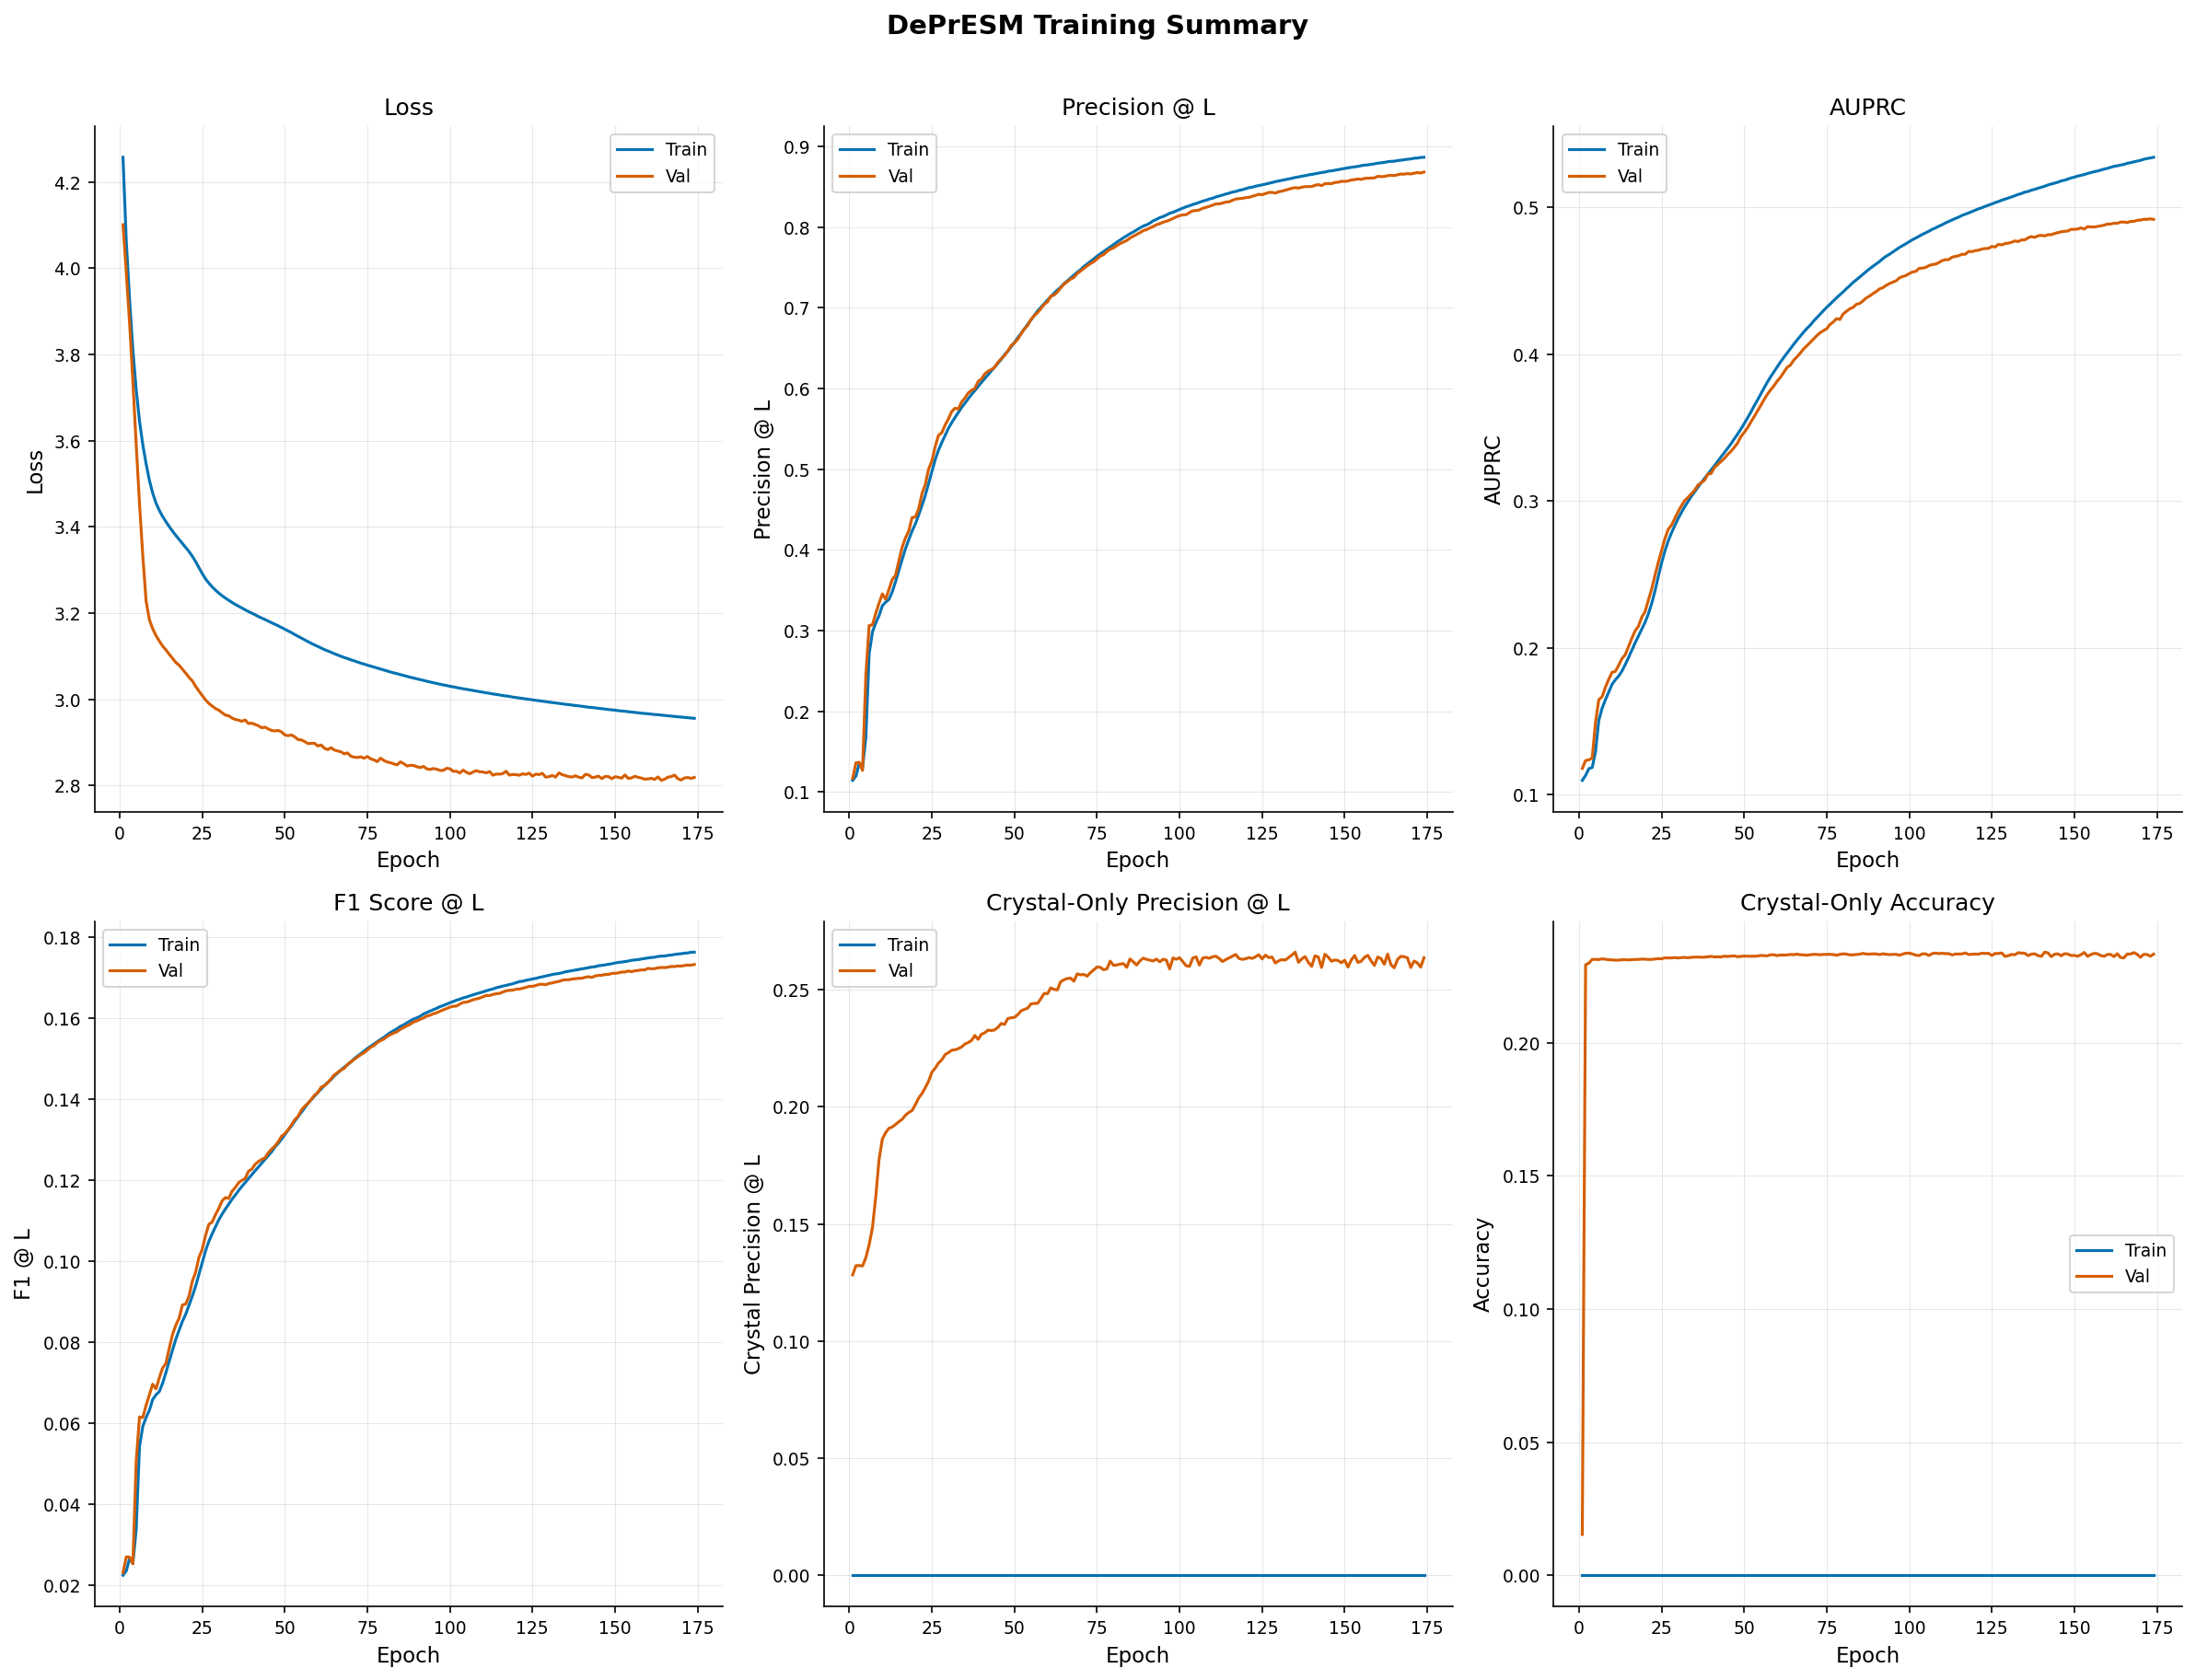

In [8]:
fig = plot_summary_dashboard(CSV_PATH, mode='view')

## Figure 7 — Cross-Run Comparison

**Description.** Side-by-side comparison of validation loss and AUPRC
across all training runs stored in `checkpoints/`. Useful for evaluating
the effect of architecture changes (e.g. embedding source, model
capacity, number of hypotheses) on convergence and final performance.

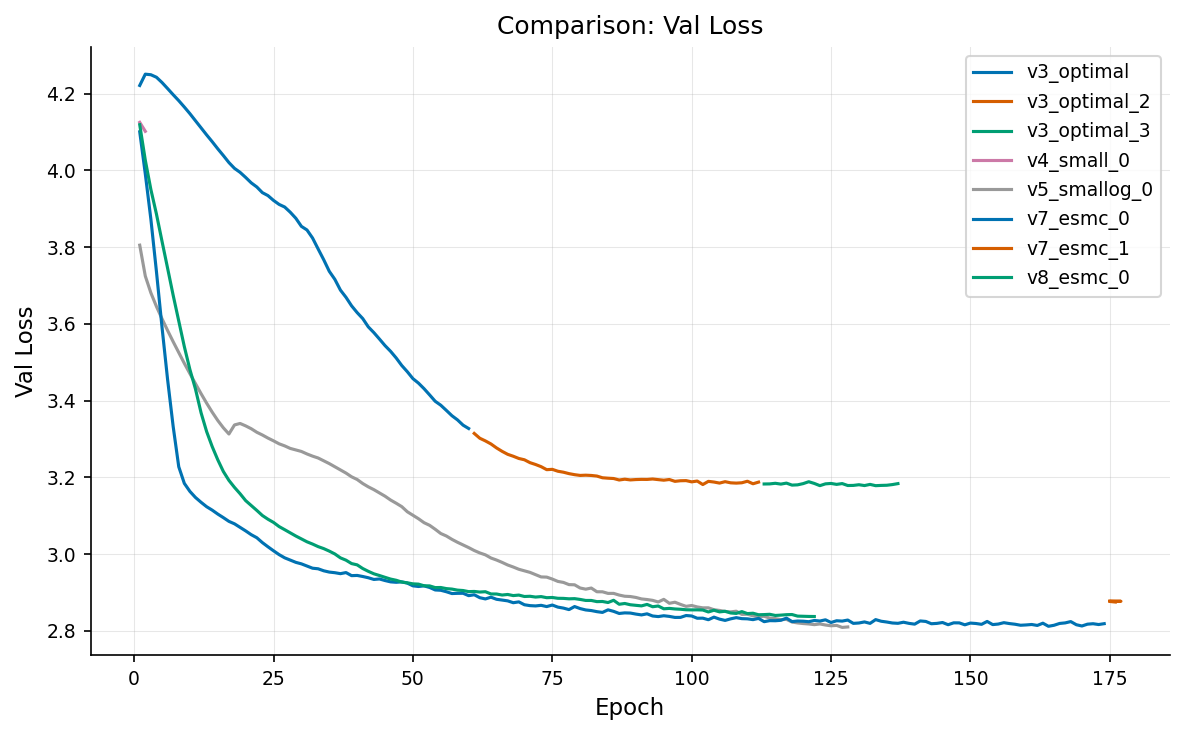

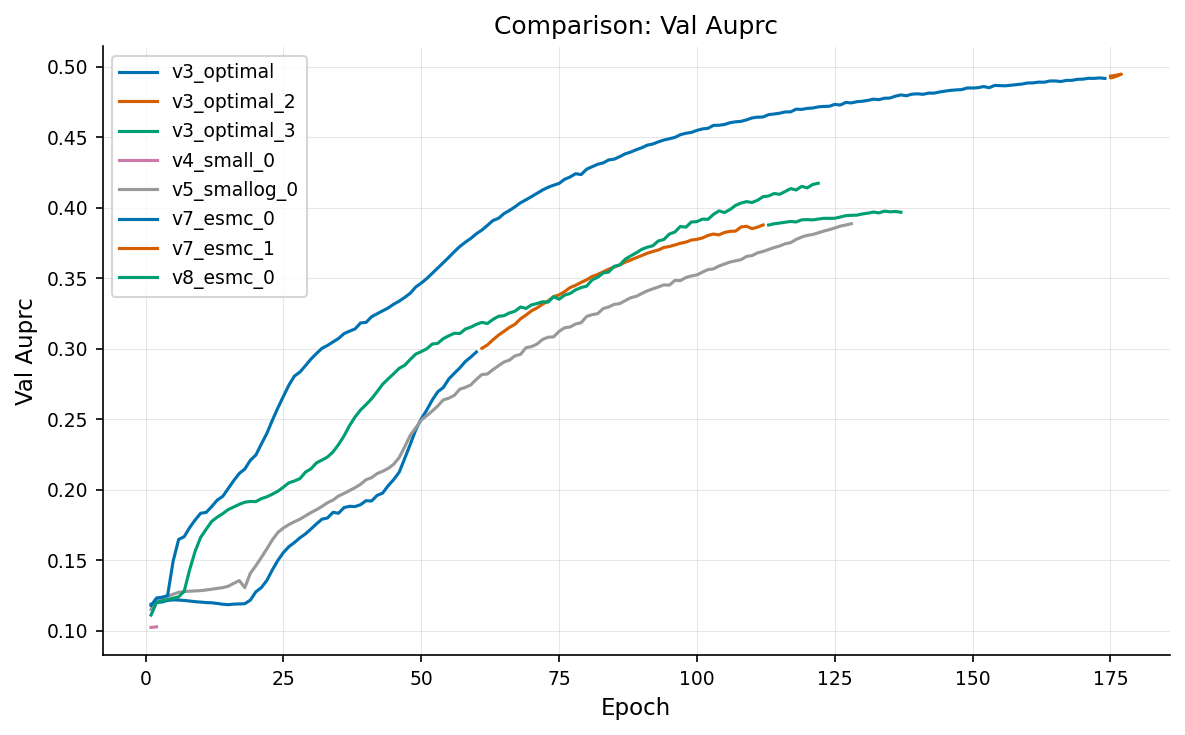

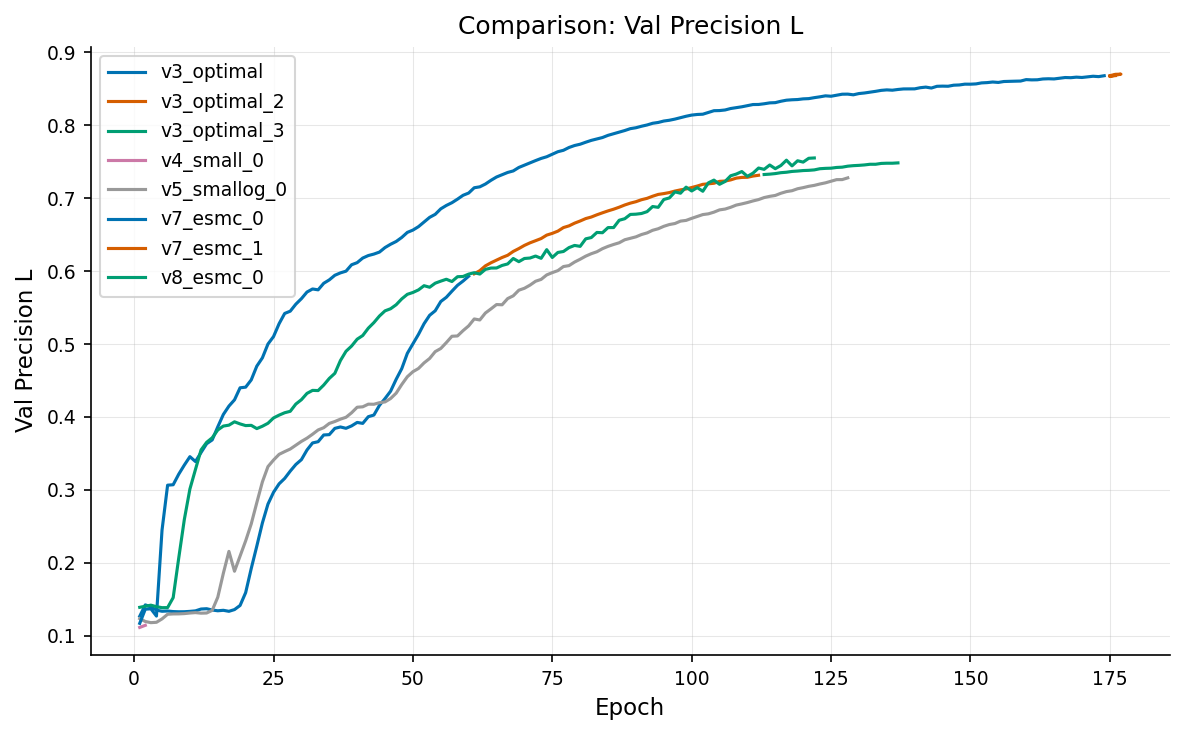

In [12]:
# Compare validation loss across different checkpoint runs
import glob

csv_files = sorted(glob.glob('../checkpoints/*/training_metrics.csv'))
run_paths = {path.split('/')[-2]: path for path in csv_files}

if len(run_paths) > 1:
    fig = plot_metric_comparison(run_paths, metric='val_loss', mode='view')
    fig = plot_metric_comparison(run_paths, metric='val_auprc', mode='view')
    fig = plot_metric_comparison(run_paths, metric='val_precision_L', mode='view')
else:
    print(f'Only one run found: {list(run_paths.keys())}')

## Export — Save All Figures as PDF

Generate all panels above as vector PDFs at 300 DPI in the `figures/`
directory. Suitable for direct inclusion in LaTeX manuscripts.

In [10]:
# Uncomment to save all figures as high-resolution PDFs
# generate_all(CSV_PATH, output_dir='../figures')